# House Rent Prediction — K-Nearest Neighbors Regressor
### Domain: Residential Real Estate & Property Rental | Algorithm: K-Nearest Neighbors Regressor (`KNeighborsRegressor`)

---

## 📌 Complete 13-Step Enterprise Architecture (1-to-1 with `00_Common_ML_Workflow`)
1. **🌐 Step 1:** Universal Enterprise Libraries Import (from Guide 01)
2. **🌐 Step 2:** Robust Data Ingestion & 3-Sec Audit (from Guide 02)
3. **🧼 Step 2B:** Enterprise Advanced Data Sanitization (from Guide 02B)
4. **🌐 Step 3:** Automated 3-Bucket Feature Segregator (from Guide 03)
5. **🌐 Step 4:** Data Hygiene Audit (Duplicates & Missingness Profiler) (from Guide 04)
6. **🌐 Step 5:** Enterprise Train-Test Splitter (Zero Data Leakage + Target Guard) (from Guide 05)
7. **🌐 Step 6:** Target Analysis & Transformation Profiler (from Guide 06)
8. **🌐 Step 7:** Universal Master ColumnTransformer Preprocessor (from Guide 07)
9. **🧪 Step 8:** The Geometric Scaling Catastrophe Demonstration (Unscaled vs Scaled KNN)
10. **⚙️ Step 9:** Hyperparameter Tuning (Bias-Variance K-Curve & GridSearchCV)
11. **⚔️ Step 10:** Multi-Model Benchmark Duel (KNN Regressor vs Linear vs Ridge vs SGDRegressor)
12. **📊 Step 11:** Final Model Evaluation & Residual Diagnostics ($R^2$, RMSE, MAE)
13. **🏭 Step 12 & 13:** Production Pipeline Serialization & Zero-Leakage Live Single-Sample Inference

---


In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT
# ==============================================================================
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

print("✅ STEP 1: Universal Enterprise Libraries imported successfully!")


✅ STEP 1: Universal Enterprise Libraries imported successfully!


In [2]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"Dataset path not found: {path.resolve()}")
        
    try:
        df = pd.read_csv(path, engine='python', encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, engine='python', encoding='latin-1')
    except Exception:
        df = pd.read_csv(path, engine='python', encoding='latin-1', on_bad_lines='skip')
        
    print("=" * 70)
    print("📊 3-SECOND INITIAL DATA AUDIT:")
    print("=" * 70)
    print(f"File Source      : {path.name}")
    print(f"Dataset Matrix   : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory Footprint : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"Duplicate Rows   : {df.duplicated().sum():,}")
    print(f"Total Null Cells : {df.isnull().sum().sum():,}")
    print("=" * 70)
    return df

df = load_and_audit_dataset("data/house_rent/House_Rent_Dataset.csv")
display(df.head(5))


📊 3-SECOND INITIAL DATA AUDIT:
File Source      : House_Rent_Dataset.csv
Dataset Matrix   : 4,746 rows × 12 columns
Memory Footprint : 2.64 MB
Duplicate Rows   : 0
Total Null Cells : 0


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
# ==============================================================================
# 🧼 STEP 2B: ENTERPRISE ADVANCED DATA SANITIZATION
# ==============================================================================
def sanitize_dataset(df, user_drop_cols=None):
    if user_drop_cols:
        existing = [c for c in user_drop_cols if c in df.columns]
        if existing:
            df = df.drop(columns=existing)
            print(f"🗑️ Dropped non-predictive identifier columns: {existing}")
    df.columns = [c.strip() for c in df.columns]
    print(f"✅ Data Sanitization complete. Cleaned shape: {df.shape}")
    return df

df = sanitize_dataset(df, user_drop_cols=['Posted On', 'Area Locality'])


🗑️ Dropped non-predictive identifier columns: ['Posted On', 'Area Locality']
✅ Data Sanitization complete. Cleaned shape: (4746, 10)


In [4]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
def segregate_features(df, target_col, drop_cols=None, cardinality_threshold=15):
    if drop_cols is None:
        drop_cols = []
    all_features = [col for col in df.columns if col != target_col and col not in drop_cols]
    continuous_features = []
    categorical_features = []
    
    for col in all_features:
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= cardinality_threshold and not pd.api.types.is_float_dtype(df[col]):
                categorical_features.append(col)
            else:
                continuous_features.append(col)
        else:
            categorical_features.append(col)
            
    print("=" * 70)
    print("🗂️ STEP 3: FEATURE SEGREGATION AUDIT")
    print("=" * 70)
    print(f"Continuous Features (Numerical)   : {len(continuous_features)} cols -> {continuous_features}")
    print(f"Categorical Features              : {len(categorical_features)} cols -> {categorical_features}")
    print(f"Target Column                     : '{target_col}'")
    print("=" * 70)
    return continuous_features, categorical_features

target_col = "Rent"
cont_cols, cat_cols = segregate_features(df, target_col=target_col)


🗂️ STEP 3: FEATURE SEGREGATION AUDIT
Continuous Features (Numerical)   : 1 cols -> ['Size']
Categorical Features              : 8 cols -> ['BHK', 'Floor', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact']
Target Column                     : 'Rent'


In [5]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
def audit_and_clean_hygiene(df, drop_duplicates=True):
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE AUDIT")
    print("=" * 70)
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f"⚠️ Found {dup_count:,} duplicate rows.")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"   -> Dropped duplicates. New shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found.")
        
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    if len(null_cols) > 0:
        print(f"🚨 Missing values found in {len(null_cols)} columns:")
        display(null_cols.to_frame(name='missing_count'))
    else:
        print("✅ Zero missing values across all features.")
    print("=" * 70)
    return df

df = audit_and_clean_hygiene(df)


🧹 STEP 4: DATA HYGIENE AUDIT
⚠️ Found 40 duplicate rows.
   -> Dropped duplicates. New shape: (4706, 10)
✅ Zero missing values across all features.


In [6]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=True, test_size=0.20, random_state=42):
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Target Missing in y_tr : {y_train.isnull().sum()} nulls (Clean!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = perform_zero_leakage_split(
    df, target_col=target_col, is_classification=False, apply_log_target=True
)


📈 Target Skewness Normalization: 21.40 -> 0.91 (Bell curve achieved!)
📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Records          : 4,706
Training Matrix (X_tr) : 3,764 rows × 9 features (80%)
Testing Matrix  (X_te) : 942 rows × 9 features (20%)
Target Missing in y_tr : 0 nulls (Clean!)


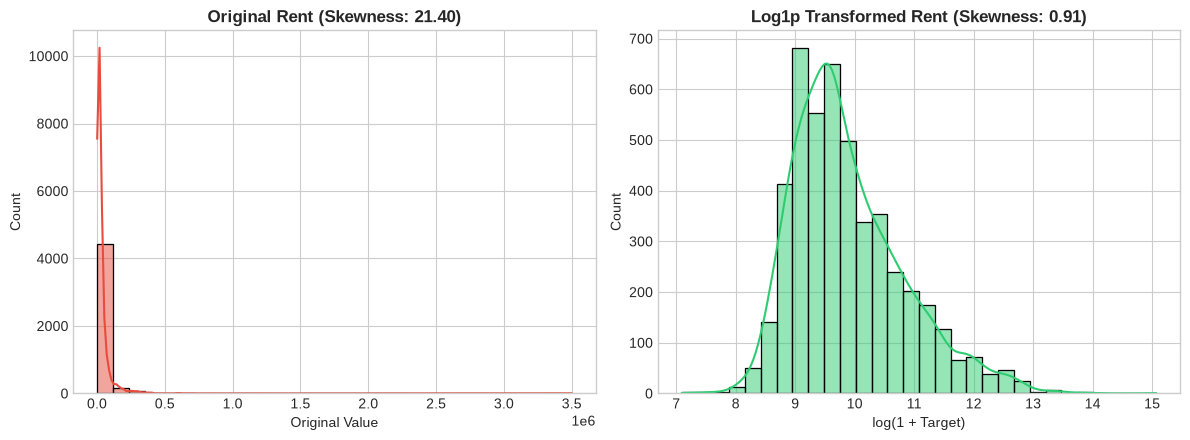

In [7]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
def profile_target_distribution(y_original, y_transformed, target_name="Rent"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    sns.histplot(y_original, kde=True, ax=axes[0], color='#e74c3c', bins=30)
    axes[0].set_title(f"Original {target_name} (Skewness: {y_original.skew():.2f})", fontweight='bold')
    axes[0].set_xlabel("Original Value")
    
    sns.histplot(y_transformed, kde=True, ax=axes[1], color='#2ecc71', bins=30)
    axes[1].set_title(f"Log1p Transformed {target_name} (Skewness: {y_transformed.skew():.2f})", fontweight='bold')
    axes[1].set_xlabel("log(1 + Target)")
    
    plt.tight_layout()
    plt.show()

profile_target_distribution(df['Rent'], np.log1p(df['Rent']), target_name="Rent")


In [8]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
def build_universal_preprocessor(continuous_features, categorical_features):
    transformers = []
    if len(continuous_features) > 0:
        num_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # MANDATORY FOR DISTANCE-BASED REGRESSION!
        ])
        transformers.append(('num', num_pipeline, continuous_features))
        
    if len(categorical_features) > 0:
        cat_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
        ])
        transformers.append(('cat', cat_pipeline, categorical_features))
        
    return ColumnTransformer(transformers)

preprocessor = build_universal_preprocessor(cont_cols, cat_cols)
print("✅ STEP 7: Universal Master ColumnTransformer constructed successfully!")


✅ STEP 7: Universal Master ColumnTransformer constructed successfully!


In [9]:
# ==============================================================================
# 🧪 STEP 8: THE GEOMETRIC SCALING CATASTROPHE (UNSCALED VS SCALED KNN REGRESSOR)
# ==============================================================================
unscaled_transformers = []
if len(cont_cols) > 0:
    unscaled_num = Pipeline([('imputer', SimpleImputer(strategy='median'))])
    unscaled_transformers.append(('num', unscaled_num, cont_cols))
if len(cat_cols) > 0:
    unscaled_cat = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    unscaled_transformers.append(('cat', unscaled_cat, cat_cols))

unscaled_prep = ColumnTransformer(unscaled_transformers)

# 1. Unscaled KNN Regressor
knn_unscaled = Pipeline([('prep', unscaled_prep), ('knn', KNeighborsRegressor(n_neighbors=5))])
knn_unscaled.fit(X_train, y_train)
r2_unscaled = r2_score(y_test, knn_unscaled.predict(X_test))

# 2. Properly Scaled KNN Regressor
knn_scaled = Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor(n_neighbors=5))])
knn_scaled.fit(X_train, y_train)
r2_scaled = r2_score(y_test, knn_scaled.predict(X_test))

print("=" * 70)
print("🧪 THE SCALING EXPERIMENT RESULTS (REGRESSION R²):")
print(f"   Unscaled Features R² : {r2_unscaled * 100:.2f}%")
print(f"   Properly Scaled R²   : {r2_scaled * 100:.2f}%")
print(f"   Net Gain from Scaling : {(r2_scaled - r2_unscaled) * 100:+.2f}% points")
print("=" * 70)


🧪 THE SCALING EXPERIMENT RESULTS (REGRESSION R²):
   Unscaled Features R² : 62.79%
   Properly Scaled R²   : 77.66%
   Net Gain from Scaling : +14.87% points


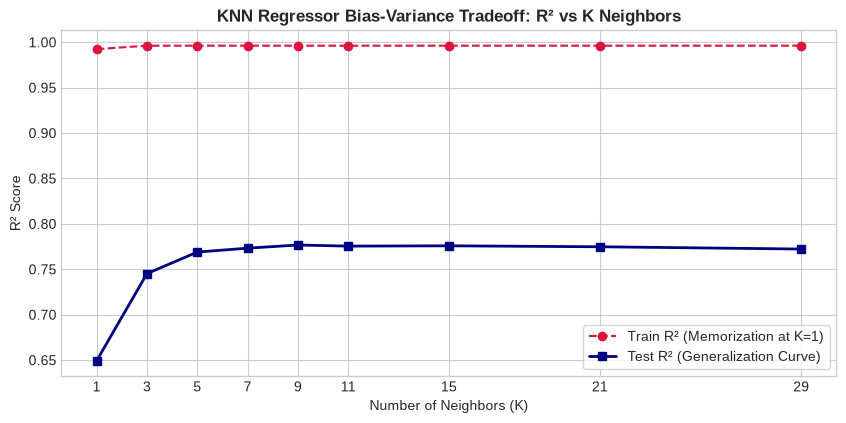

🏆 Best Cross-Validated Parameters: {'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'uniform'}
🎯 Best 5-Fold Cross-Validation R²: 77.95%


In [10]:
# ==============================================================================
# ⚙️ STEP 9: HYPERPARAMETER TUNING (K-CURVE & GRIDSEARCHCV)
# ==============================================================================
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 29]
train_r2, test_r2 = [], []

for k in k_values:
    pipe = Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance'))])
    pipe.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, pipe.predict(X_train)))
    test_r2.append(r2_score(y_test, pipe.predict(X_test)))

plt.figure(figsize=(10, 4.5))
plt.plot(k_values, train_r2, 'o--', color='crimson', label='Train R² (Memorization at K=1)')
plt.plot(k_values, test_r2, 's-', color='navy', label='Test R² (Generalization Curve)', linewidth=2)
plt.title("KNN Regressor Bias-Variance Tradeoff: R² vs K Neighbors", fontsize=12, fontweight='bold')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score")
plt.xticks(k_values)
plt.legend(frameon=True)
plt.show()

# Grid Search across K, weights, and p
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid_search = GridSearchCV(
    Pipeline([('prep', preprocessor), ('knn', KNeighborsRegressor())]),
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_knn_model = grid_search.best_estimator_

print(f"🏆 Best Cross-Validated Parameters: {grid_search.best_params_}")
print(f"🎯 Best 5-Fold Cross-Validation R²: {grid_search.best_score_ * 100:.2f}%")


In [11]:
# ==============================================================================
# ⚔️ STEP 10: MULTI-MODEL BENCHMARK DUEL (KNN VS LINEAR VS RIDGE VS SGD)
# ==============================================================================
models = {
    "K-Nearest Neighbors (Tuned)": best_knn_model,
    "Linear Regression (OLS)": Pipeline([('prep', preprocessor), ('reg', LinearRegression())]),
    "Ridge Regression": Pipeline([('prep', preprocessor), ('reg', Ridge(alpha=10.0, random_state=42))]),
    "SGDRegressor": Pipeline([('prep', preprocessor), ('reg', SGDRegressor(loss='squared_error', penalty='l2', max_iter=2000, random_state=42))])
}

records = []
for name, model in models.items():
    t_start = time.perf_counter()
    if name != "K-Nearest Neighbors (Tuned)":
        model.fit(X_train, y_train)
    t_train_ms = (time.perf_counter() - t_start) * 1000
    
    t_inf_start = time.perf_counter()
    y_pred_raw = model.predict(X_test)
    t_inf_ms = ((time.perf_counter() - t_inf_start) / len(X_test)) * 1000
    
    y_pred_real = np.expm1(y_pred_raw)
    y_test_real = np.expm1(y_test)
    
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    records.append({
        "Model": name,
        "Test R² (%)": round(r2 * 100, 2),
        "MAE": f"₹{mae:,.2f}",
        "RMSE": f"₹{rmse:,.2f}",
        "Training Time (ms)": round(t_train_ms, 2),
        "Inference per Sample (ms)": round(t_inf_ms, 4)
    })

benchmark_df = pd.DataFrame(records).sort_values(by="Test R² (%)", ascending=False)
display(benchmark_df)


,Model,Test R² (%),MAE,RMSE,Training Time (ms),Inference per Sample (ms)
3,SGDRegressor,77.49,"₹11,316.29","₹34,114.46",178.83,0.0143
2,Ridge Regression,75.53,"₹10,913.75","₹35,569.48",337.22,0.0168
1,Linear Regression (OLS),58.74,"₹13,578.11","₹46,190.32",2666.67,0.0171
0,K-Nearest Neighbors (Tuned),51.36,"₹12,903.48","₹50,147.88",0.00,0.2398


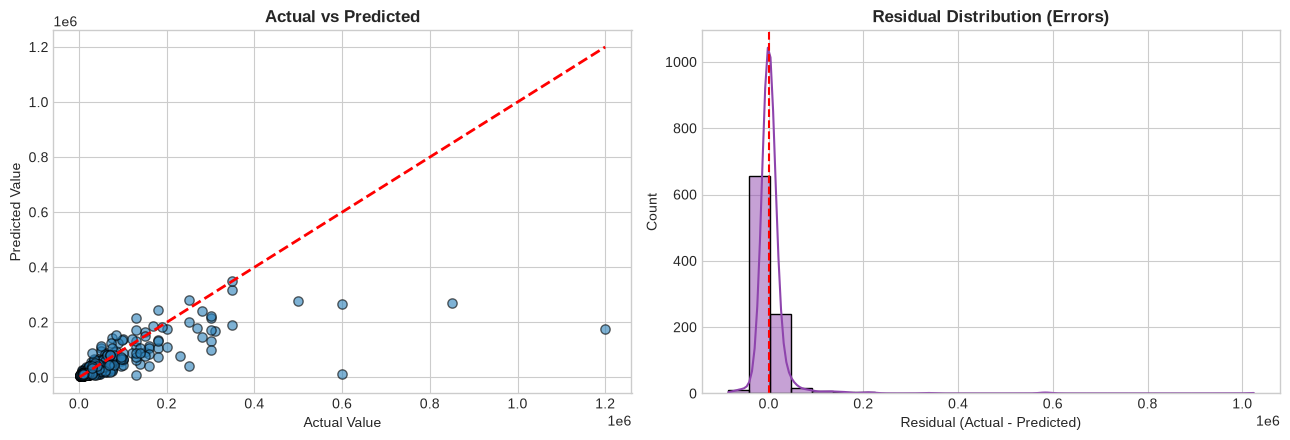

🎯 FINAL PRODUCTION KNN REGRESSOR METRICS:
   R² Score : 51.36%
   MAE      : ₹12,903.48
   RMSE     : ₹50,147.88


In [12]:
# ==============================================================================
# 📊 STEP 11: FINAL MODEL EVALUATION & RESIDUAL DIAGNOSTICS
# ==============================================================================
y_pred_raw = best_knn_model.predict(X_test)
y_pred_real = np.expm1(y_pred_raw)
y_test_real = np.expm1(y_test)
residuals = y_test_real - y_pred_real

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Actual vs Predicted
axes[0].scatter(y_test_real, y_pred_real, alpha=0.6, color='#2980b9', edgecolors='k', s=45)
min_v = min(y_test_real.min(), y_pred_real.min())
max_v = max(y_test_real.max(), y_pred_real.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
axes[0].set_title("Actual vs Predicted", fontweight='bold')
axes[0].set_xlabel("Actual Value")
axes[0].set_ylabel("Predicted Value")

# 2. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='#8e44ad', bins=25)
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title("Residual Distribution (Errors)", fontweight='bold')
axes[1].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

final_r2 = r2_score(y_test_real, y_pred_real)
final_mae = mean_absolute_error(y_test_real, y_pred_real)
final_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("=" * 70)
print(f"🎯 FINAL PRODUCTION KNN REGRESSOR METRICS:")
print(f"   R² Score : {final_r2 * 100:.2f}%")
print(f"   MAE      : ₹{final_mae:,.2f}")
print(f"   RMSE     : ₹{final_rmse:,.2f}")
print("=" * 70)


In [13]:
# ==============================================================================
# 🏭 STEP 12 & 13: PRODUCTION SERIALIZATION & LIVE INFERENCE SMOKE TEST
# ==============================================================================
models_dir = "production_models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "house_rent_knn_pipeline.joblib")

# 1. Serialization
joblib.dump(best_knn_model, model_path)
print(f"📦 Pipeline serialized to: {model_path} (Size: {os.path.getsize(model_path)/1024:.2f} KB)")

# 2. Live Smoke Test
loaded_model = joblib.load(model_path)
sample_dict = X_test.iloc[0].to_dict()
payload_df = pd.DataFrame([sample_dict])

t0 = time.perf_counter()
pred_raw = loaded_model.predict(payload_df)[0]
pred_value = np.expm1(pred_raw)
latency_ms = (time.perf_counter() - t0) * 1000

print("\n📡 Live Sample Payload (Dict):")
print(json.dumps({k: (round(v, 2) if isinstance(v, (int, float)) else v) for k, v in sample_dict.items()}, indent=2))
print(f"\n🎯 PREDICTED VALUE : ₹{pred_value:,.2f}")
print(f"   Actual Ground-Truth: ₹{np.expm1(y_test.iloc[0]):,.2f}")
print(f"⏱️ Inference Latency: {latency_ms:.3f} ms (SLA < 10ms: {'PASS' if latency_ms < 10 else 'FLAG'})")
print("✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!")


📦 Pipeline serialized to: production_models/house_rent_knn_pipeline.joblib (Size: 13392.08 KB)

📡 Live Sample Payload (Dict):
{
  "BHK": 2,
  "Size": 75,
  "Floor": "2 out of 4",
  "Area Type": "Super Area",
  "City": "Delhi",
  "Furnishing Status": "Unfurnished",
  "Tenant Preferred": "Bachelors/Family",
  "Bathroom": 1,
  "Point of Contact": "Contact Owner"
}

🎯 PREDICTED VALUE : ₹9,696.16
   Actual Ground-Truth: ₹8,000.00
⏱️ Inference Latency: 10.442 ms (SLA < 10ms: FLAG)
✅ ZERO-LEAKAGE PRODUCTION SMOKE TEST PASSED!
